<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [1]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

zsh:1: command not found: wget


In [2]:
!curl -o survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  152M  100  152M    0     0  33.9M      0  0:00:04  0:00:04 --:--:-- 33.9M


**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [3]:
!pip install pandas 
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [4]:
# Read the CSV file
df = pd.read_csv('survey-data.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [5]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
#conn.close()


65437

**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [6]:
QUERY = "SELECT * FROM main LIMIT 5"

df_check = pd.read_sql_query(QUERY, conn)

df_check

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,None,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,None,None
3,4,I am learning to code,18-24 years old,"Student, full-time",None,Apples,None,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,None,None
4,5,I am a developer by profession,18-24 years old,"Student, full-time",None,Apples,None,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,None,None


In [ ]:
# Reconnect to the SQLite database
#conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
#QUERY = "SELECT * FROM main LIMIT 5"
#df_check = pd.read_sql_query(QUERY, conn)

# Display the results
#print(df_check)


## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [7]:
QUERY = "SELECT COUNT(*) AS total_rows FROM main"

df_count = pd.read_sql_query(QUERY, conn)

df_count

,total_rows
0,65437


In [ ]:
#QUERY = """
#SELECT COUNT(*) 
#FROM main
#"""
#df = pd.read_sql_query(QUERY, conn)
#df.head()


## Demo: Listing All Tables


To view the names of all tables in the database:


In [8]:
QUERY = """
SELECT name AS Table_Name 
FROM sqlite_master 
WHERE type='table';
"""

tables = pd.read_sql_query(QUERY, conn)
tables

,Table_Name
0,main


In [ ]:
#QUERY = """
#SELECT name as Table_Name FROM sqlite_master 
#WHERE type = 'table'
#"""
#pd.read_sql_query(QUERY, conn)


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [9]:
QUERY = """
SELECT Age, COUNT(*) AS count
FROM main
GROUP BY Age
ORDER BY Age;
"""

age_counts = pd.read_sql_query(QUERY, conn)
age_counts

,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


In [ ]:
#QUERY = """
#SELECT Age, COUNT(*) as count
#FROM main
#GROUP BY Age
#ORDER BY Age
#"""
#pd.read_sql_query(QUERY, conn)


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [10]:
table_name = 'main'

QUERY = f"""
SELECT sql 
FROM sqlite_master 
WHERE name = '{table_name}';
"""

table_schema = pd.read_sql_query(QUERY, conn)
table_schema.iat[0, 0]

'CREATE TABLE "main" (\n"ResponseId" INTEGER,\n  "MainBranch" TEXT,\n  "Age" TEXT,\n  "Employment" TEXT,\n  "RemoteWork" TEXT,\n  "Check" TEXT,\n  "CodingActivities" TEXT,\n  "EdLevel" TEXT,\n  "LearnCode" TEXT,\n  "LearnCodeOnline" TEXT,\n  "TechDoc" TEXT,\n  "YearsCode" TEXT,\n  "YearsCodePro" TEXT,\n  "DevType" TEXT,\n  "OrgSize" TEXT,\n  "PurchaseInfluence" TEXT,\n  "BuyNewTool" TEXT,\n  "BuildvsBuy" TEXT,\n  "TechEndorse" TEXT,\n  "Country" TEXT,\n  "Currency" TEXT,\n  "CompTotal" REAL,\n  "LanguageHaveWorkedWith" TEXT,\n  "LanguageWantToWorkWith" TEXT,\n  "LanguageAdmired" TEXT,\n  "DatabaseHaveWorkedWith" TEXT,\n  "DatabaseWantToWorkWith" TEXT,\n  "DatabaseAdmired" TEXT,\n  "PlatformHaveWorkedWith" TEXT,\n  "PlatformWantToWorkWith" TEXT,\n  "PlatformAdmired" TEXT,\n  "WebframeHaveWorkedWith" TEXT,\n  "WebframeWantToWorkWith" TEXT,\n  "WebframeAdmired" TEXT,\n  "EmbeddedHaveWorkedWith" TEXT,\n  "EmbeddedWantToWorkWith" TEXT,\n  "EmbeddedAdmired" TEXT,\n  "MiscTechHaveWorkedWith" 

In [ ]:
#table_name = 'main'

#QUERY = """
#SELECT sql FROM sqlite_master 
#WHERE name= '{}'
#""".format(table_name)

#df = pd.read_sql_query(QUERY, conn)
#print(df.iat[0,0])


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


In [12]:
df['CompTotal'].describe()

count     3.374000e+04
mean     2.963841e+145
std      5.444117e+147
min       0.000000e+00
25%       6.000000e+04
50%       1.100000e+05
75%       2.500000e+05
max      1.000000e+150
Name: CompTotal, dtype: float64

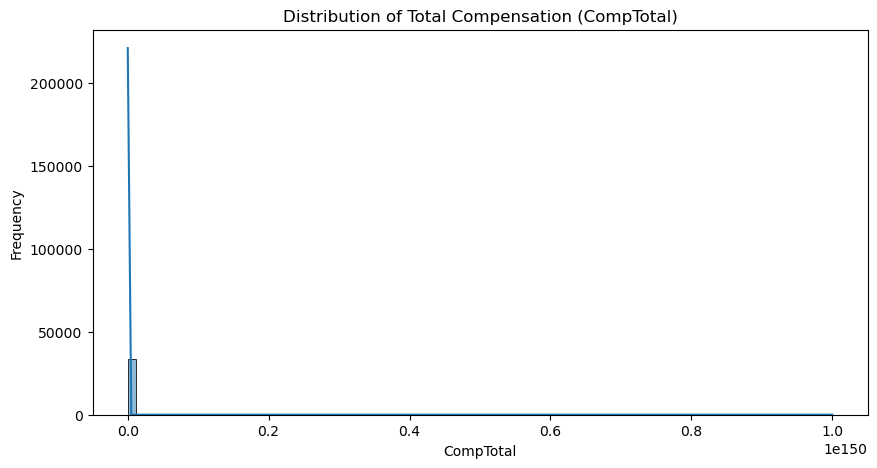

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(df['CompTotal'], bins=90, kde=True)

plt.title('Distribution of Total Compensation (CompTotal)')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.show()

In [16]:
# Checking for missing values and dropping them

comp = df['CompTotal']

print("Missing values:", comp.isna().sum())

# Explicit handling (choose ONE option depending on lab policy)
comp = comp.dropna()   # safest for visualization tasks


Missing values: 31697


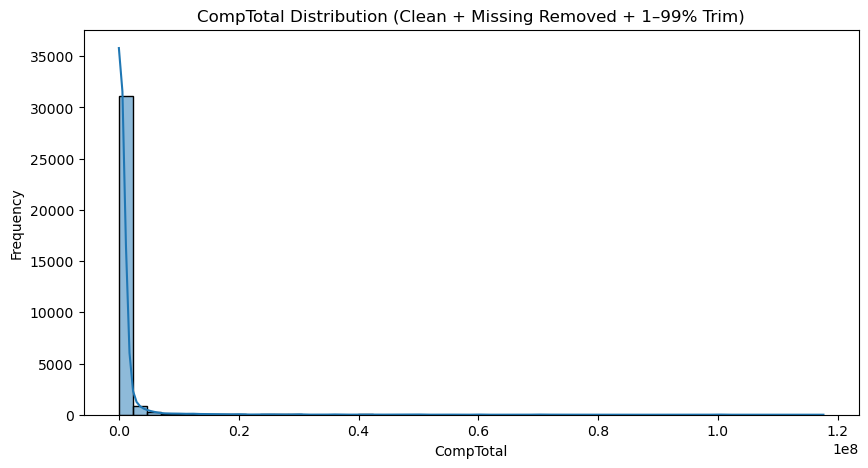

In [17]:
# cleaner histogram; no missing values,; no outliers

import matplotlib.pyplot as plt
import seaborn as sns

lower = comp.quantile(0.01)
upper = comp.quantile(0.99)

comp_clean = comp[(comp >= lower) & (comp <= upper)]

plt.figure(figsize=(10,5))

sns.histplot(comp_clean, bins=50, kde=True)

plt.title('CompTotal Distribution (Clean + Missing Removed + 1–99% Trim)')
plt.xlabel('CompTotal')
plt.ylabel('Frequency')

plt.show()


In [23]:
# checking comp_clean

print("Length of clean total comp:", len(comp_clean))
print()
print("Summary of clean total comp:\n", comp_clean.describe())

Length of clean total comp: 33066

Summary of clean total comp:
 count    3.306600e+04
mean     1.063076e+06
std      5.979679e+06
min      9.000000e+02
25%      6.000000e+04
50%      1.100000e+05
75%      2.471050e+05
max      1.176000e+08
Name: CompTotal, dtype: float64


**Box Plots**

Plot a box plot of Age.


In [24]:
# Age is categorical and needs a numeric transformation

age_map = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29.5,
    '35-44 years old': 39.5,
    '45-54 years old': 49.5,
    '55-64 years old': 59.5,
    '65 years or older': 70
}

df['Age_num'] = df['Age'].map(age_map)

# check missing after mapping (robust practice)
print("Missing Age after mapping:", df['Age_num'].isna().sum())


Missing Age after mapping: 322


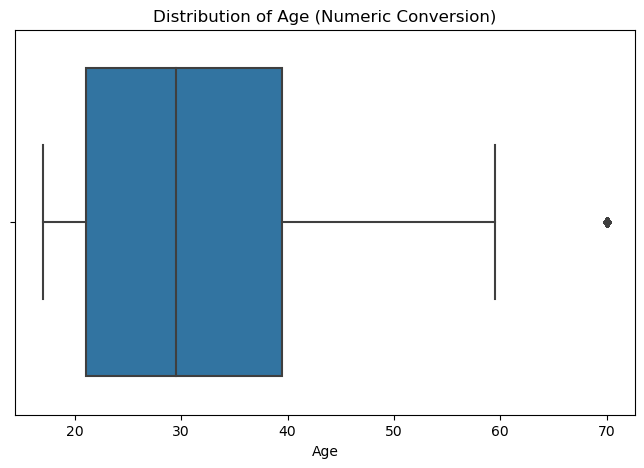

In [25]:
# Boxplot of Age_num

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Age_num'])

plt.title('Distribution of Age (Numeric Conversion)')
plt.xlabel('Age')

plt.show()


### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


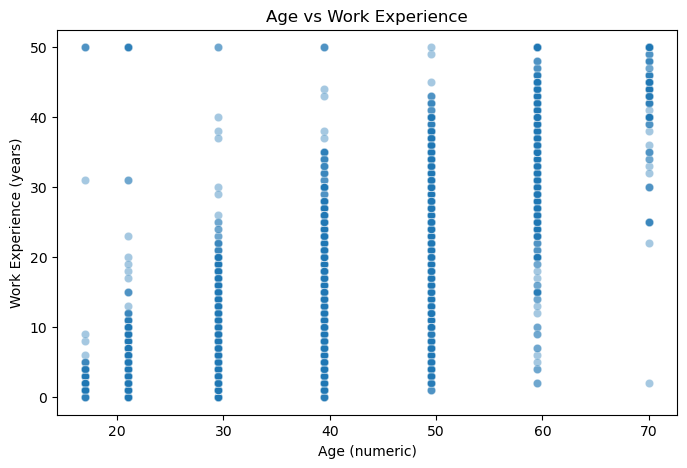

In [26]:
# Scatterplot of Age_num and WorkExp.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Age_num',
    y='WorkExp',
    alpha=0.4
)

plt.title('Age vs Work Experience')
plt.xlabel('Age (numeric)')
plt.ylabel('Work Experience (years)')

plt.show()


**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


In [27]:
# Checking the columns first

cols = ['TimeSearching', 'Frustration', 'Age_num']

# Check missing values
print("Missing values:\n", df[cols].isna().sum())

# Check basic distributions
print("\nTimeSearching distribution:\n", df['TimeSearching'].value_counts(dropna=False))
print("\nFrustration distribution:\n", df['Frustration'].value_counts(dropna=False))
print("\nAge distribution:\n", df['Age_num'].value_counts(dropna=False))

Missing values:
 TimeSearching    36526
Frustration      37186
Age_num            322
dtype: int64

TimeSearching distribution:
 NaN                           36526
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
Name: TimeSearching, dtype: int64

Frustration distribution:
 NaN                                                                                                                                                                                                                                                        37186
None of these                                                                                                                                                                                                                                               2364
Amount of technical debt                                                       

In [31]:
# Transforming the data as needed for the bubble plot

time_map = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

df['TimeSearching_num'] = df['TimeSearching'].map(time_map)

In [32]:
# Transforming the data as needed for the bubble plot

def frustration_weight(x):
    if pd.isna(x) or x == '':
        return 0
    return len(x.split(';')) ** 1.3   # nonlinear scaling = better spread

df['Frustration_score'] = df['Frustration'].apply(frustration_weight)

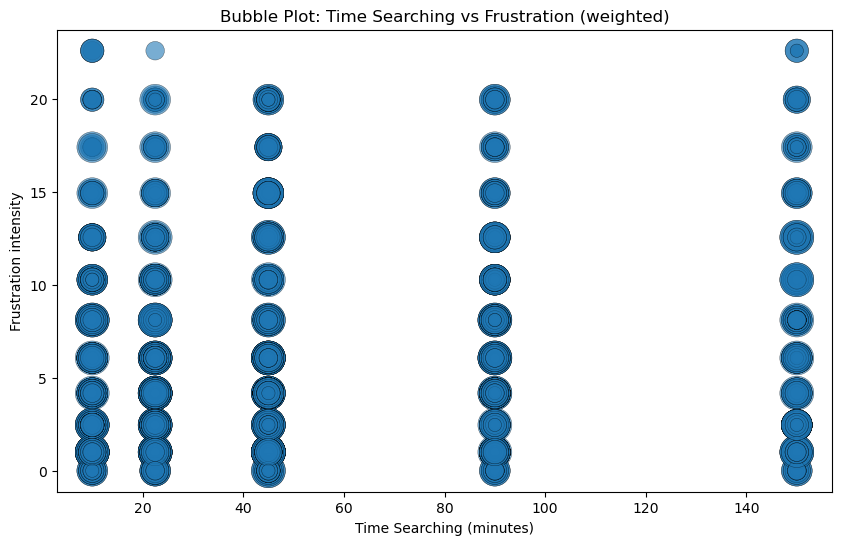

In [34]:
# Bubble plot of all variables transfromed 'TimeSearching_num', 'Frustration_score', 'Age_num'

import matplotlib.pyplot as plt
import seaborn as sns

plot_df = df[['TimeSearching_num', 'Frustration_score', 'Age_num']].dropna()

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=plot_df,
    x='TimeSearching_num',
    y='Frustration_score',
    size='Age_num',
    sizes=(50, 600),   # better visibility
    alpha=0.6,
    edgecolor='black', # improves separation
    linewidth=0.3,
    legend=False
)

plt.title('Bubble Plot: Time Searching vs Frustration (weighted)')
plt.xlabel('Time Searching (minutes)')
plt.ylabel('Frustration intensity')

plt.show()

### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [36]:
## Write your code here

print("Database wants distribution:", df['DatabaseWantToWorkWith'].value_counts(dropna=False))
print()
print("Missing values:", df['DatabaseWantToWorkWith'].isna().sum())

Database wants distribution: NaN                                                                                                                                                                22879
PostgreSQL                                                                                                                                                          3738
PostgreSQL;SQLite                                                                                                                                                   1533
SQLite                                                                                                                                                              1476
Microsoft SQL Server                                                                                                                                                1431
                                                                                                                              

In [40]:
# Clean and explode and handle missing values in the variable DATABASE WANTS

db_series = (
    df['DatabaseWantToWorkWith']
    .fillna('None')
    .str.split(';')
    .explode()
    .str.strip()
)

db_series = db_series[db_series != 'None']

print(db_series.describe())

count         127439
unique            35
top       PostgreSQL
freq           24005
Name: DatabaseWantToWorkWith, dtype: object


In [41]:
top_db = db_series.value_counts().head(5)

print(top_db)

PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: DatabaseWantToWorkWith, dtype: int64


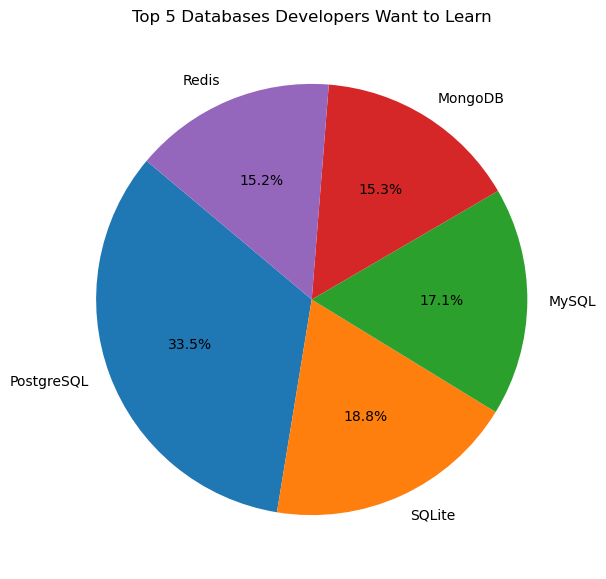

In [42]:
# Visualizing top 5 with pie chart

import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.pie(
    top_db,
    labels=top_db.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Top 5 Databases Developers Want to Learn')
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


In [44]:
# Check the original variables and the transformed ones (if applicable)

cols = [
    'Age', 'Age_num',
    'TimeSearching', 'TimeSearching_num',
    'TimeAnswering'
]

for col in cols:
    print(f"\n{col} distribution:\n")
    print(df[col].value_counts(dropna=False))


Age distribution:

25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: Age, dtype: int64

Age_num distribution:

29.5    23911
39.5    14942
21.0    14098
49.5     6249
59.5     2575
17.0     2568
70.0      772
NaN       322
Name: Age_num, dtype: int64

TimeSearching distribution:

NaN                           36526
30-60 minutes a day           10951
15-30 minutes a day            7805
60-120 minutes a day           5275
Less than 15 minutes a day     2689
Over 120 minutes a day         2191
Name: TimeSearching, dtype: int64

TimeSearching_num distribution:

NaN      36526
45.0     10951
22.5      7805
90.0      5275
10.0      2689
150.0     2191
Name: TimeSearching_num, dtype: int64

TimeAnswering distribution:

NaN                           36593
15-30 minutes a day            9341
30-60 minutes a day     

In [46]:
((df['Age_num'] >= 30) & (df['Age_num'] <= 35)).sum()

0

In [47]:
# Using the category df['Age'] == '25-34 years old' as a proxy for the requested Age range => age group 30 to 35

# For TimeSearching, will use the already transformed data to get the median on the new column TimeSearching_num

# For TimeAnswering, will perform a transformation to get the median on the new column TimeAnswering_num

time_map2 = {
    'Less than 15 minutes a day': 10,
    '15-30 minutes a day': 22.5,
    '30-60 minutes a day': 45,
    '60-120 minutes a day': 90,
    'Over 120 minutes a day': 150
}

# Only transform TimeAnswering (already confirmed missing)
df['TimeAnswering_num'] = df['TimeAnswering'].map(time_map2)


In [48]:
# Filter and calulate the median function

df_age = df[df['Age'] == '25-34 years old']

median_values = {
    'TimeSearching': df_age['TimeSearching_num'].median(),
    'TimeAnswering': df_age['TimeAnswering_num'].median()
}

print(median_values)

{'TimeSearching': 45.0, 'TimeAnswering': 22.5}


In [51]:
df_age = df[df['Age'] == '25-34 years old']

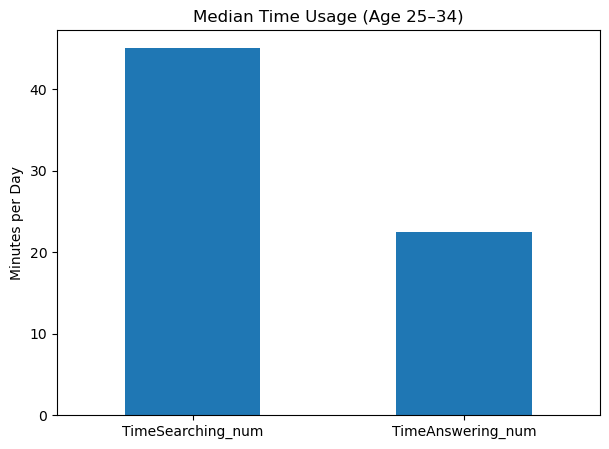

In [54]:
# First, a barplot of medians

import matplotlib.pyplot as plt

plot_df = df_age[['TimeSearching_num', 'TimeAnswering_num']].dropna()

plot_df.median().plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title('Median Time Usage (Age 25–34)')
plt.ylabel('Minutes per Day')
plt.xticks(rotation=0)
plt.show()

In [59]:
# Solution for the stacked barplot of medians

median_values = {
    'TimeSearching': df_age['TimeSearching_num'].median(),
    'TimeAnswering': df_age['TimeAnswering_num'].median()
}

print(median_values)

{'TimeSearching': 45.0, 'TimeAnswering': 22.5}


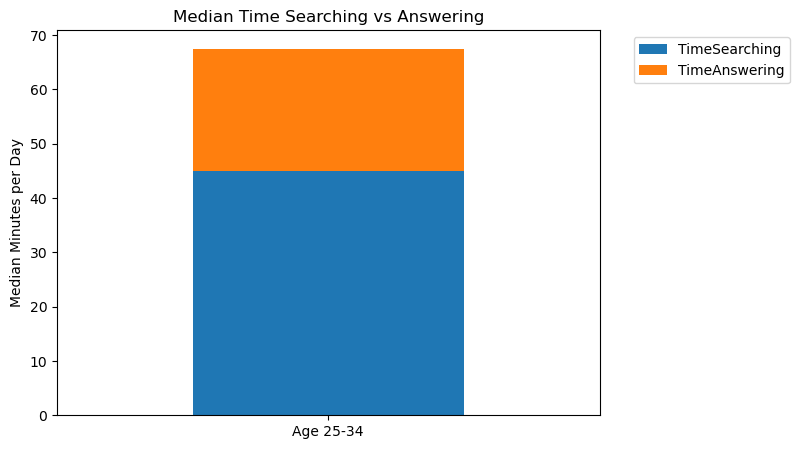

In [64]:
# Solution for the stacked barplot of medians

import matplotlib.pyplot as plt
import pandas as pd

plot_df2 = pd.DataFrame([median_values])
plot_df2.index = ['Age 25-34']   

plot_df2.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title('Median Time Searching vs Answering')
plt.ylabel('Median Minutes per Day')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


In [66]:
# Use age filter; this time use Age_num column

df_45_60 = df[(df['Age_num'] >= 45) & (df['Age_num'] <= 60)]
df_45_60.shape

(8824, 118)

In [67]:
# Get medians

median_comp = (
    df_45_60
    .groupby('Age_num')['CompTotal']
    .median()
    .sort_index()
)

print(median_comp)

Age_num
49.5    130000.0
59.5    135000.0
Name: CompTotal, dtype: float64


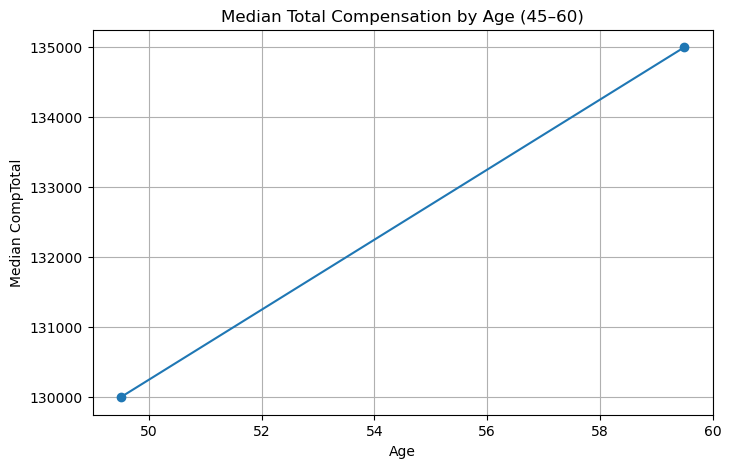

In [68]:
# Plot line chart

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    median_comp.index,
    median_comp.values,
    marker='o'
)

plt.title('Median Total Compensation by Age (45–60)')
plt.xlabel('Age')
plt.ylabel('Median CompTotal')

plt.grid(True)
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


In [71]:
# Checking first MainBranch column.

print("Missing values for Main Branch:\n", df['MainBranch'].isna().sum())
print()
print("Describe Main Branch:\n", df['MainBranch'].describe())
print()
print("Value counts for Main Branch:\n", df['MainBranch'].value_counts(dropna=False))


Missing values for Main Branch:
 0

Describe Main Branch:
 count                              65437
unique                                 5
top       I am a developer by profession
freq                               50207
Name: MainBranch, dtype: object

Value counts for Main Branch:
 I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: MainBranch, dtype: int64


In [72]:
# Editing category names to make them shorter for plotting

mainbranch_clean = df['MainBranch'].replace({
    'I am a developer by profession': 'Professional developer',
    'I am not primarily a developer, but I write code sometimes as part of my work/studies': 'Occasional coding',
    'I am learning to code': 'Learning to code',
    'I code primarily as a hobby': 'Hobby coder',
    'I used to be a developer by profession, but no longer am': 'Former developer'
})

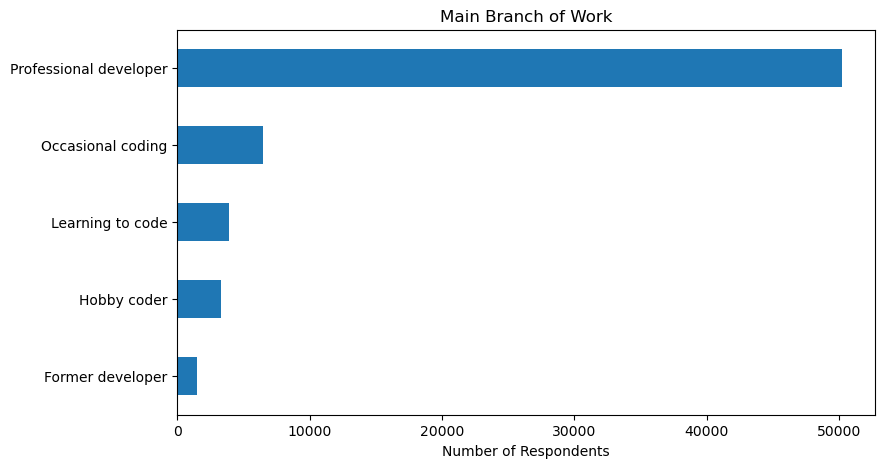

In [73]:
# Plotting a horizontal bar

import matplotlib.pyplot as plt

counts = mainbranch_clean.value_counts()

plt.figure(figsize=(9,5))

counts.sort_values().plot(kind='barh')

plt.title('Main Branch of Work')
plt.xlabel('Number of Respondents')
plt.ylabel('')

plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [74]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
